In [7]:
import pandas as pandy
import numpy as numpy
import matplotlib.pyplot as mplot

In [8]:
pff_df = pandy.read_csv("../Data/raw/forestfires.csv")
pff_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), str(2)
memory usage: 52.6 KB


In [9]:
pff_df.head(10)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


In [10]:
pff_df.describe().round(2)

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00
mean,4.67,4.30,90.64,110.87,547.94,9.02,18.89,44.29,4.02,0.02,12.85
std,2.31,1.23,5.52,64.05,248.07,4.56,5.81,16.32,1.79,0.30,63.66
min,1.00,2.00,18.70,1.10,7.90,0.00,2.20,15.00,0.40,0.00,0.00
25%,3.00,4.00,90.20,68.60,437.70,6.50,15.50,33.00,2.70,0.00,0.00
50%,4.00,4.00,91.60,108.30,664.20,8.40,19.30,42.00,4.00,0.00,0.52
75%,7.00,5.00,92.90,142.40,713.90,10.80,22.80,53.00,4.90,0.00,6.57
max,9.00,9.00,96.20,291.30,860.60,56.10,33.30,100.00,9.40,6.40,1090.84


----------------------------------------------------
***Distributions***

Summary Stats — min, max, mean, median, etc

Histograms - temp, RH, wind, rain, FFMC, DMC, DC, ISI, area, aka numeric columns

Bar charts - month, day, aka categorical columns

--------------------------------------------------

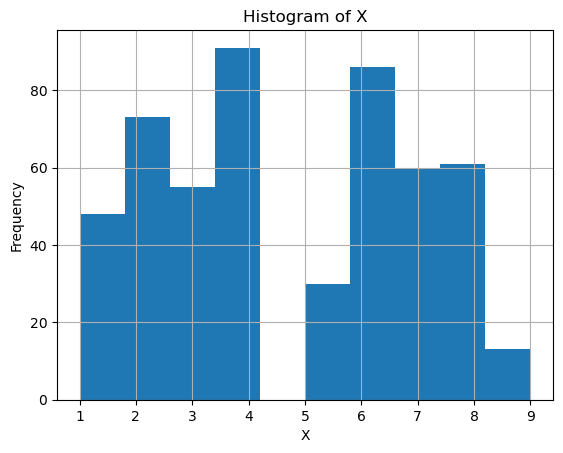

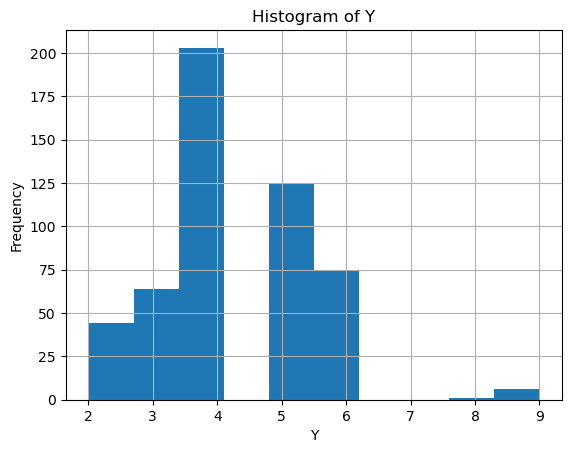

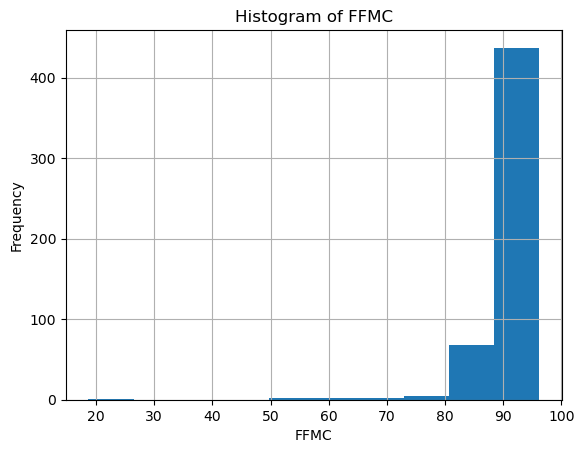

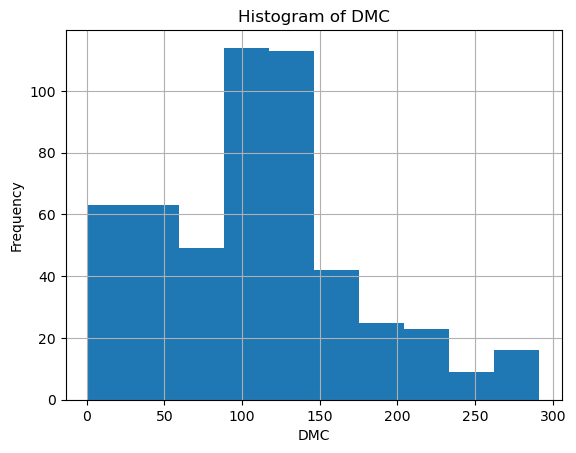

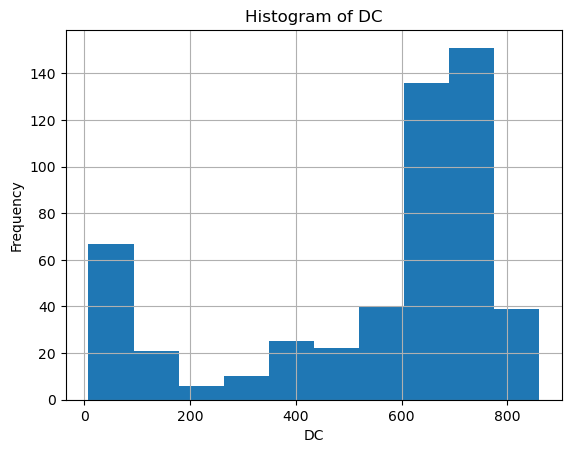

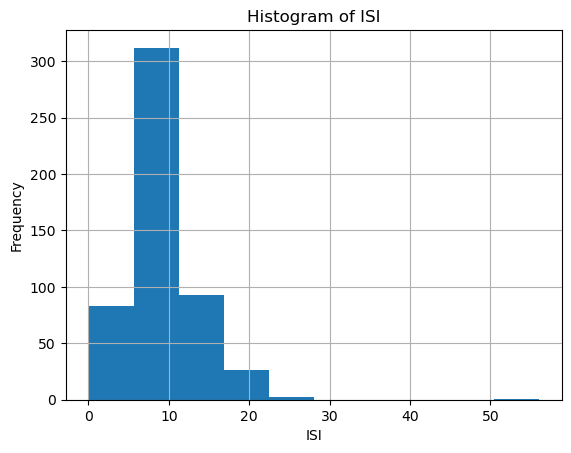

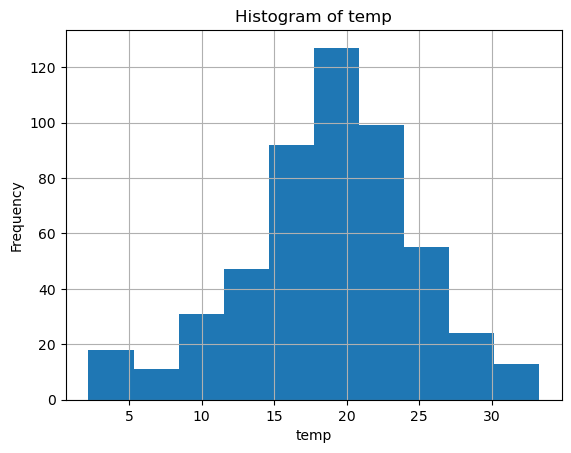

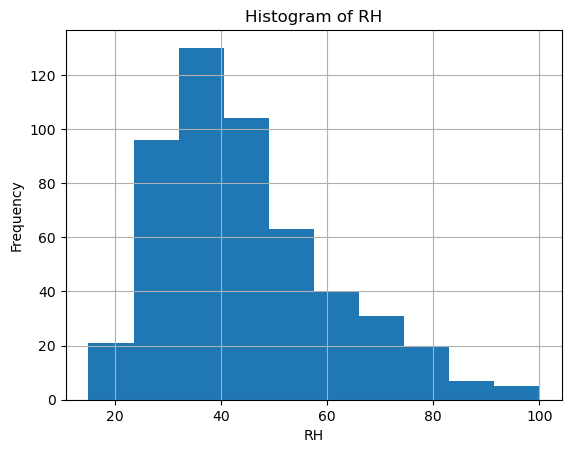

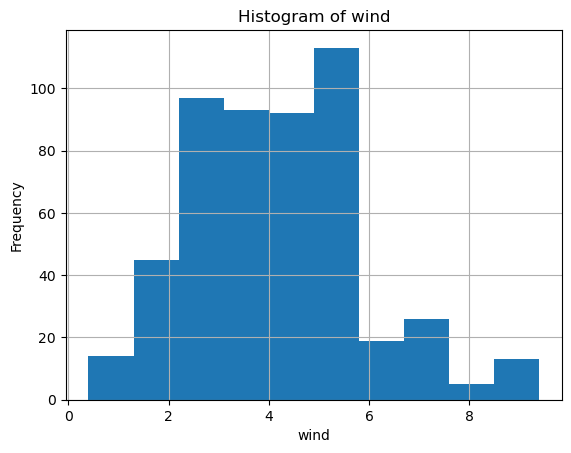

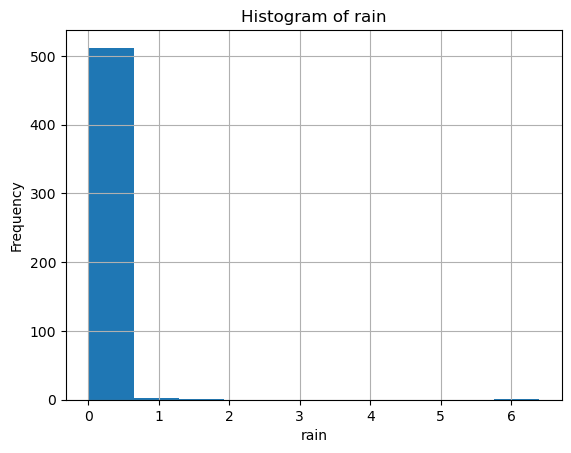

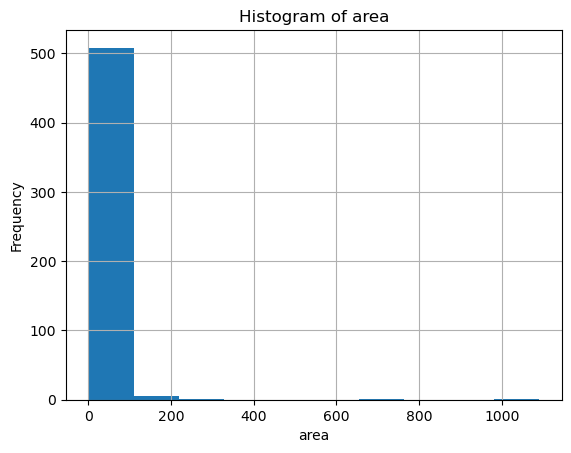

In [11]:
for c in pff_df:
    if c in pff_df.describe():
        mplot.figure()
        pff_df[c].hist()
        mplot.title(f"Histogram of {c}")
        mplot.xlabel(c)
        mplot.ylabel("Frequency")

---------------------------------------------------------------
**Observations**

Temperature has a nice symmetric bell-shaped curve to it. 

Wind and Relative Humidity (RH) had similar shapes, with a clear middle point peak, but the shapes were more dramatic and less symmetric. RH was slightly right skewed I believe, with a long tail.

X and Y are grid-based, map positions, so not really relevant here. 

FFMC shows a few outliers in the lower ratings, with most of the high frequency of fires around the 90 mark. Ratings of 90 and above are consider very high and extreme predictors for human-caused ignition.

DMC is slightly skewed to the right, with the highest peak around 100-150. According to FWI Systems, any ratings over 60 count as extreme. With a mean of 110, that means the average moisture content of this area is a highly likely source of lightning-caused ignition risk.

DC slightly skews to the left, with the highest peaks at 600-800. Any rating over 500 is considered highly extreme, which lends to the assumption that seasonal drought can also be a strong predictor for forest fires.

The mean for ISI is approx a rating of 9. The histogram reflects that, being right skewed. ISI measures wind speed, with higher values indicating faster spread. Most fires in this dataset spread at a moderate-high rate. Perhaps ISI is not a strong enough factor for prediction, but still worth measuring as a feature.

Rain and Area have the most intense differences in their histogram. With very little variation, I don't believe rain to be an important factor to be considered for modeling or further analysis at this time. Perhaps drought (DC) should be looked into further.

Area has the highest skew of all the histograms and data. Further exploration is needed here to get a fuller picture of how Area interacts with the other variables before modeling.

Overall, this dataset follows logical and expected patterns of potential forest fire ignition risks, causes and behavior. Drought, Temperature, lightning and human caused ignition, DMC's rating of medium sized woody material, and low relative humidity all seem to be strong and important predictors to evaluate and model on.

There does not seem to be any correlation yet with any of these potential fire ignition and spread risks to area, suggesting the strongest predictors here are for whether a fire will start or spread, and not how large or what area the fire will grow and cover. 

-------------------------------------------------------------

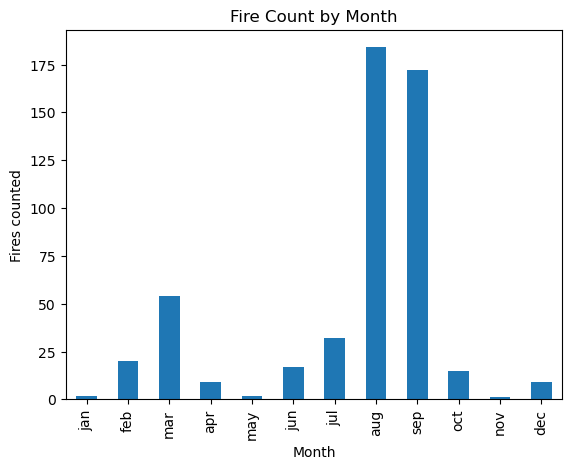

In [12]:
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
day_order = ['mon','tue','wed','thu','fri','sat','sun']

# Month Bar Chart

mplot.figure()
pff_df['month'].value_counts().reindex(month_order).plot(kind='bar')
mplot.title("Fire Count by Month")
mplot.xlabel("Month")
mplot.ylabel("Fires counted")
mplot.show()



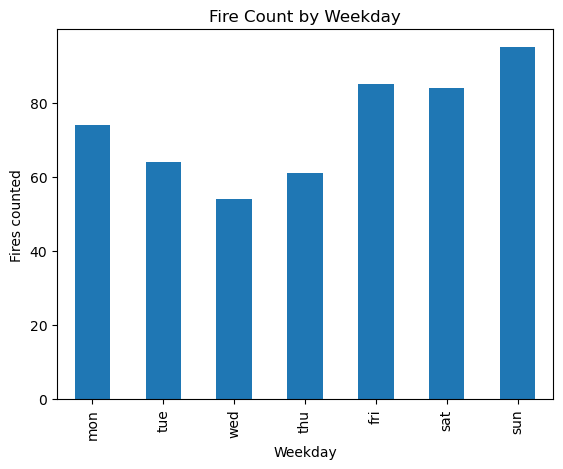

In [13]:
# Day Bar Chart

mplot.figure()
pff_df['day'].value_counts().reindex(day_order).plot(kind='bar')
mplot.title("Fire Count by Weekday")
mplot.xlabel("Weekday")
mplot.ylabel("Fires counted")
mplot.show()

***Relationships***

Scatter plots - weather variables/numerics

Boxplots - burned area grouped by month and day/categorical

-----------------------------------------------------------

In [14]:
feature_columns = pff_df.loc[:,['FFMC','DMC','DC','ISI','temp','RH','wind']]
feature_columns.info()

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FFMC    517 non-null    float64
 1   DMC     517 non-null    float64
 2   DC      517 non-null    float64
 3   ISI     517 non-null    float64
 4   temp    517 non-null    float64
 5   RH      517 non-null    int64  
 6   wind    517 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 28.4 KB


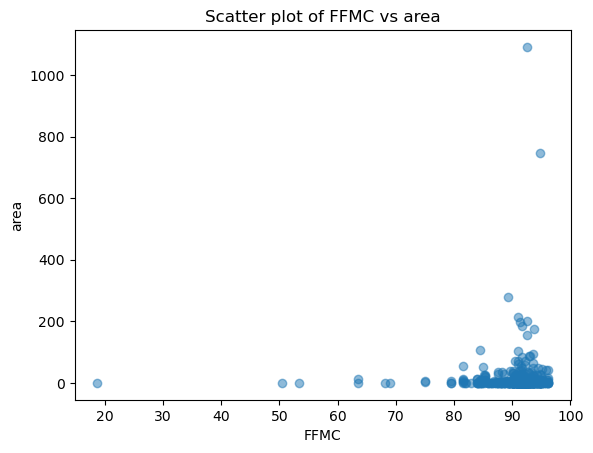

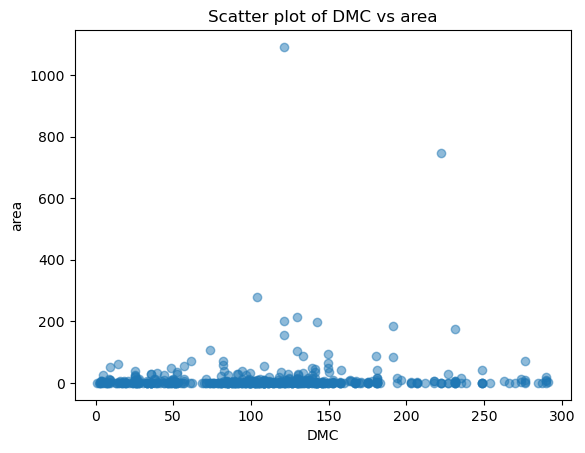

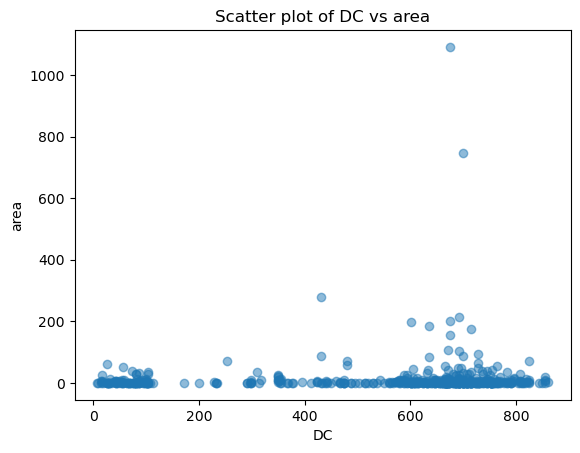

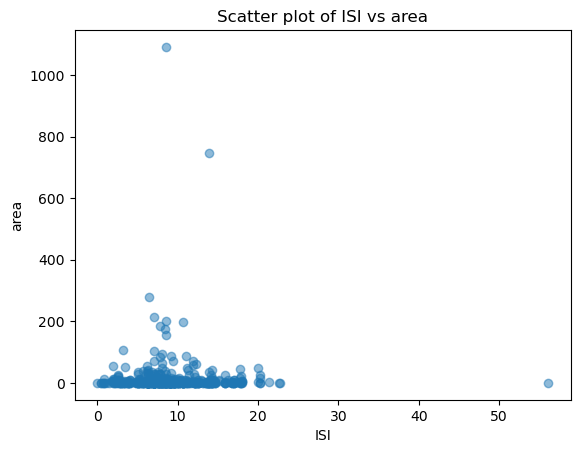

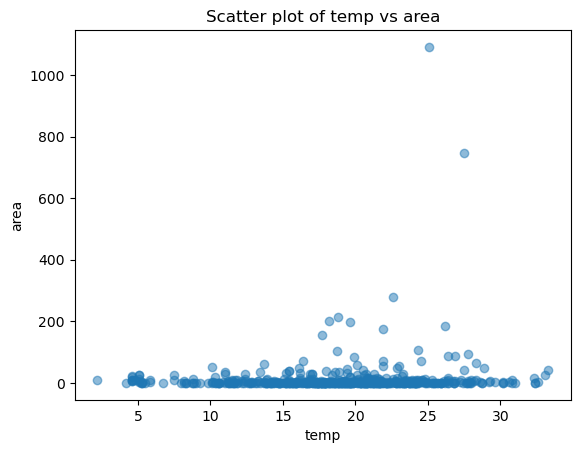

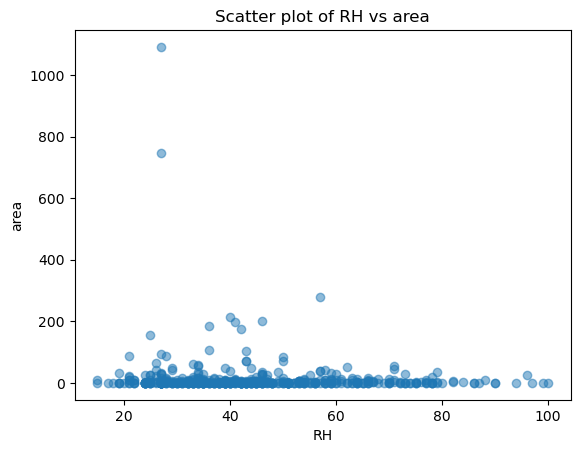

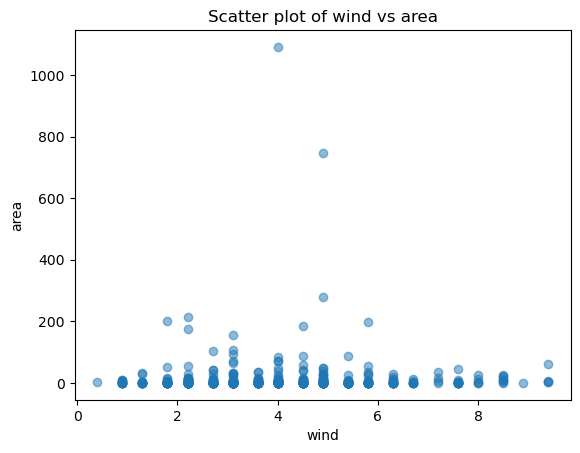

In [15]:
for c in feature_columns:
    mplot.figure()
    mplot.scatter(feature_columns[c], pff_df['area'], alpha=0.5)
    mplot.title(f"Scatter plot of {c} vs area")
    mplot.xlabel(c)
    mplot.ylabel("area")

-----------------------------------------------------
***Observations***

Vast majority of plot points linger around the 0.0 area mark, which is to be expected after earlier exploration. There are a few outliers in each scatter plot that occur much farther than 0.0, but I'm not sure how to interpret these outliers at this time.

Density seems to be the best way to interpret most of these plots.

FFFMC: Giant chunk of plots in the 80-100 zone. 2 major outliers at approx 750 and 1100. Not sure if this is a strong predictor for forest fires, or just a correlation. Classified as sustainable flaming ignition, I don't believe this will be considered a strong predictor for a linear regression model. Perhaps something non linear?

DMC: Still at the 0 area mark, but a line of mostly even spread with high density. At around 150 the density seems to slightly diminish, but there is still a clear line. A few outliers at approx 1100 and 750 inline with the FFMC outliers. No obvious sign of any real significant trend with lightning ignition probability. 

DC: There is an interesting shape/pattern here. Again the same outliers at approx 1100 and 750. Highest density of points around 0 area, but there is a moderate amount in the window of 0-200 as well. There is a small chunk of small fires at the low end, but the majority are large fires past 400 DC, with the most between 600-800. This lines up with the histograms. I believe it makes a slight fan shape here, but hard to say b/c of the 0.0 area skewing results. There is definitely a relationship worth exploring here, but I can't say anything definitely at this time. 

ISI: There are the 2 same outliers from before, but a new one at the rating of ISI 55. The highest ISI rating is seen as very extreme past 16, but this is interesting to note. I still don't think ISI is a strong candidate for fire prediction. There doesn't seem to be a strong pattern or relationship here.

Temp: Highest density is between 10-30 points. No clear pattern here again, weak relationship, but again could be because of the area being skewed by 0.

-----------------------------------------------------

**Because of the initial area variable skewing the data, I will apply a logarithmic transformation to help examine the relationships better, as suggested by the source authors!!**

----------------------------------------------------------

In [16]:
pff_df['log_area'] = numpy.log1p(pff_df['area'])

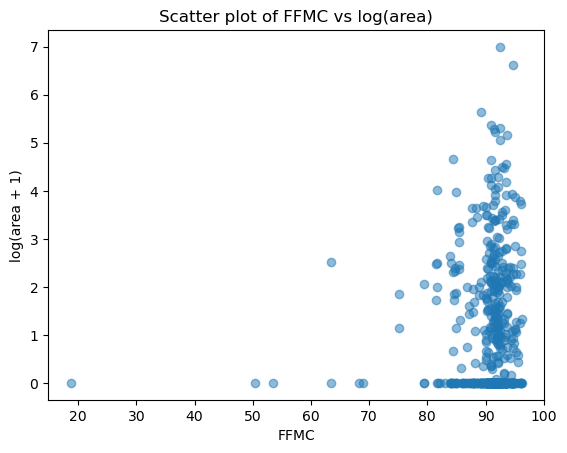

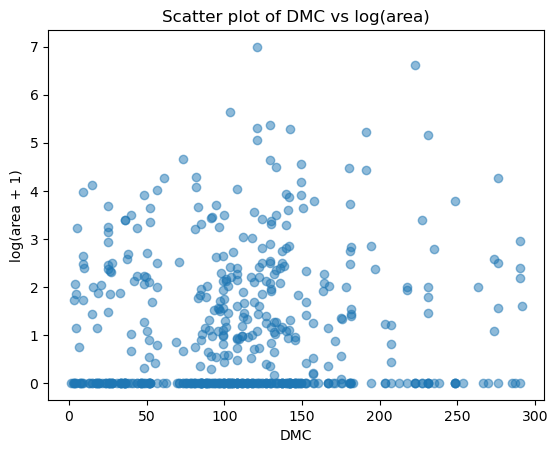

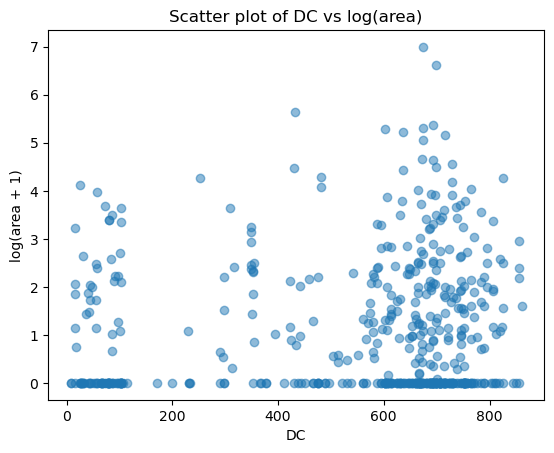

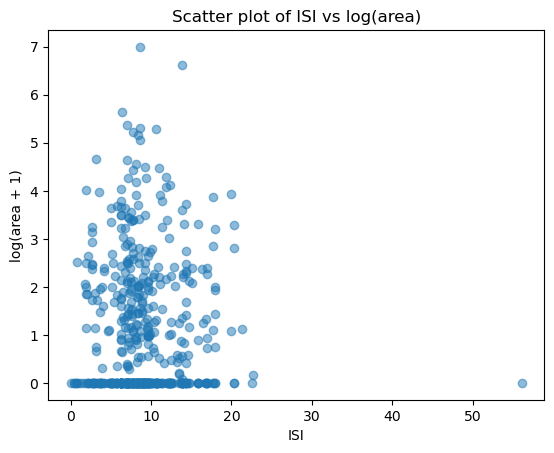

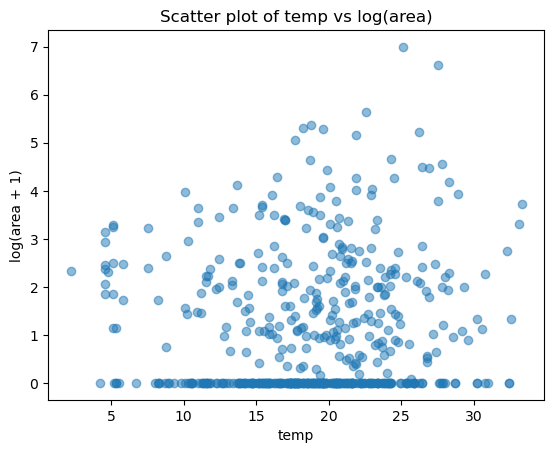

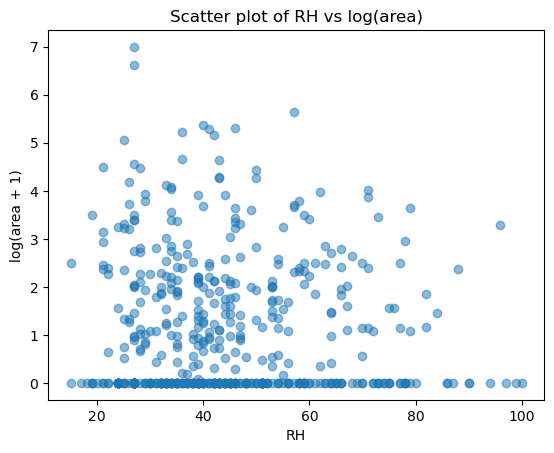

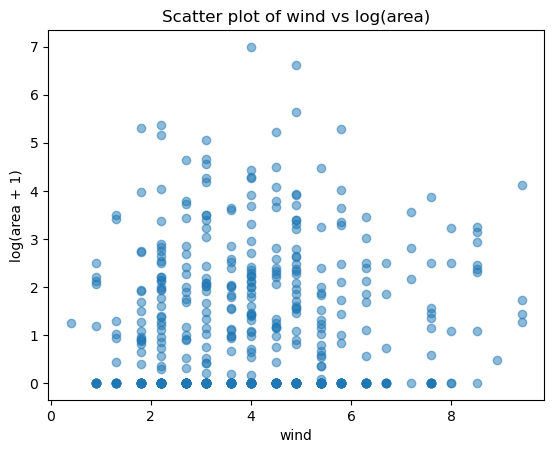

In [17]:
for c in feature_columns:
    mplot.figure()
    mplot.scatter(feature_columns[c], pff_df['log_area'], alpha=0.5)
    mplot.title(f"Scatter plot of {c} vs log(area)")
    mplot.xlabel(c)
    mplot.ylabel("log(area + 1)")

--------------------------------------------------------
***Observations***

Using log brings more clarity, but doesn't really change my observations. 

FFMC - Verticle shape is clearer at the high end range of 80+. 

DMC: still no clear pattern or shape.

DC: Still similar shape here, with clumps at the very low and high end, and a moderate density in between. No real sign of strong pattern or shape.

ISI: Again same observations, no strong relationship here.

Temp: No clear patterns or relationships here.

RH: No real patterns, weak correlation.

Wind: interesting shapes visually, but again no clear pattern here.

Overall FFMC has the strongest pattern here, but it's still relatively weak.

Where to go from here?

-----------------------------------------------------

<Figure size 640x480 with 0 Axes>

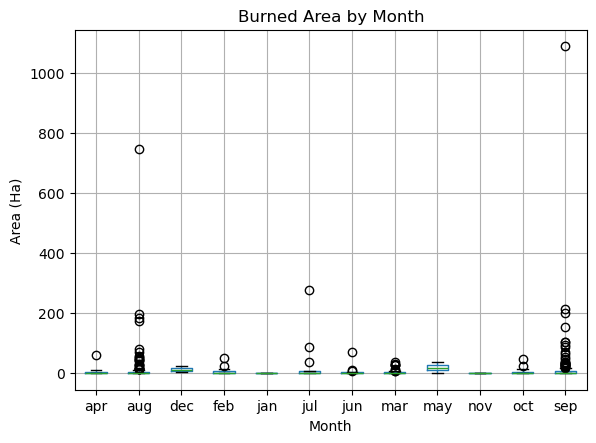

In [18]:
# Boxplot of Burned Area by Month

mplot.figure()
pff_df.boxplot(column='area', by='month')
mplot.title("Burned Area by Month")
mplot.suptitle("")  # removes the default extra title pandas adds
mplot.xlabel("Month")
mplot.ylabel("Area (Ha)")
mplot.show()

<Figure size 640x480 with 0 Axes>

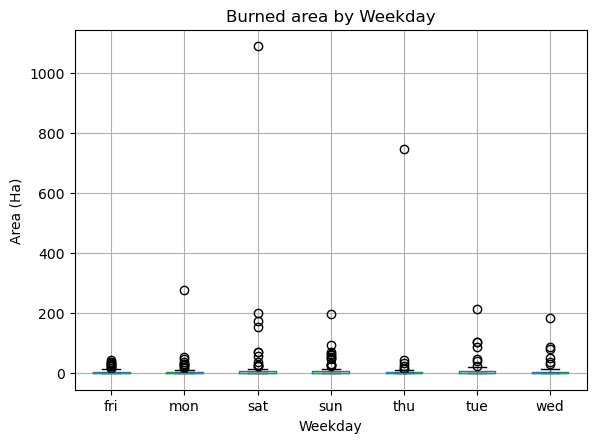

In [19]:
# Boxplot of Burned Area by Day

mplot.figure()
pff_df.boxplot(column='area', by='day')
mplot.title("Burned area by Weekday")
mplot.suptitle("")
mplot.xlabel("Weekday")
mplot.ylabel("Area (Ha)")
mplot.show()

***Data Quality Issues***

Missing values: none

Duplicate rows: not sure yet

Zero Skewing Area: Noted use of log transformation!